<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

**Автор**: Ермекова Асель


В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.
Результат вашей лучшей модели будет оцениваться на тестовой выборке по метрике Accuracy. Эта часть оценивается до 5 баллов.

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.70$ --- 4 балла

3) $0.70 > score \geqslant 0.60$ --- 3 балла

4) $0.60 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.25$ --- 1 балл

6) $0.25 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на три части.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.

В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается до 5 баллов.

### Peer-review
Вторая часть будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


# **Environmental Sound Classification**

## **Task Overview**

В этом домашнем задании вам предстоит работать с датасетом различных звуков окружающей среды (собака, дождь, плач ребёнка и т. д.).

### **Part 1: Create Dataset**

Первым делом давайте скачаем датасет и прилагающие csv файлы с метками класса.

In [1]:
# !pip install gdown

In [2]:
# import os
# os.makedirs("data", exist_ok=True)

# # Скачиваем файлы в папку data
# !gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO -O data/sound_classification_dataset.zip
# !gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT -O data/train.csv
# !gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 -O data/valid.csv
# !gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks -O data/test.csv

# # Разархивируем в папку data


In [3]:
# !gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO # sound_classification_dataset.zip
# !gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT # train.csv
# !gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 # valid.csv
# !gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks # test.csv

Разархивируйте zip файл, где содержатся wav файлы датасета.

In [4]:
# !unzip -q data/sound_classification_dataset.zip -d data/

In [5]:
# !unzip /content/sound_classification_dataset.zip

In [6]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
warnings.filterwarnings("ignore")

In [7]:
import torch
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset
import os
import torch.nn as nn
import torch.nn.functional as F
import random

In [8]:
path = 'data/'
# path = ''

In [9]:
train_df = pd.read_csv(path + "train.csv")
valid_df = pd.read_csv(path + "valid.csv")
test_df = pd.read_csv(path + "test.csv")

In [10]:
train_df.head()

,filename,category
0,1-100032-A-0.wav,dog
1,1-110389-A-0.wav,dog
2,1-17367-A-10.wav,rain
3,1-187207-A-20.wav,crying_baby
4,1-211527-A-20.wav,crying_baby


In [11]:
valid_df.head()

,filename,category
0,4-156843-A-21.wav,sneezing
1,4-156844-A-21.wav,sneezing
2,4-157297-A-21.wav,sneezing
3,4-160999-A-10.wav,rain
4,4-161127-A-10.wav,rain


In [12]:
test_df.head()

,filename
0,5-151085-A-20.wav
1,5-181766-A-10.wav
2,5-187979-A-21.wav
3,5-188655-A-10.wav
4,5-193339-A-10.wav


Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

In [13]:
import torch
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset
import pandas as pd
import os
import torch.nn as nn
import torch.nn.functional as F
import random
import librosa
import numpy as np

class SimpleAudioDataset(Dataset):
    """A dataset to load, preprocess, and augment audio files."""

    def __init__(self, df, audio_dir="data/sound_classification_dataset", target_length_sec=2.0, sample_rate=16000, do_augmentation=False, has_labels=True):
        # here is your code
        self.df = df
        self.audio_dir = audio_dir
        self.target_length = int(target_length_sec * sample_rate)
        self.sample_rate = sample_rate
        self.do_augmentation = do_augmentation
        self.has_labels = has_labels
        
        # Create mapping from category names to indices only if labels exist
        if has_labels:
            self.classes = sorted(df['category'].unique())
            self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        else:
            self.classes = None
            self.class_to_idx = None

    def __len__(self):
        # here is your code
        return len(self.df)

    def __getitem__(self, index):
        # 1. Get the file path
        # here is your code
        filename = self.df.iloc[index]['filename']
        audio_file_path = os.path.join(self.audio_dir, filename)
        
        # Get label only if dataset has labels
        if self.has_labels:
            label = self.class_to_idx[self.df.iloc[index]['category']]
        else:
            label = -1  # dummy label for test set

        # 2. LOAD: Load the raw audio file using librosa
        # here is your code
        audio_array, sample_rate = librosa.load(audio_file_path, sr=None, mono=True)
        signal = torch.from_numpy(audio_array).float()  # shape: (samples,)
        
        # 3. PREPROCESS: Apply the preprocessing steps
        # Add channel dimension for resampling (channels, samples)
        signal = signal.unsqueeze(0)  # shape: (1, samples)
        signal = self._resample(signal, sample_rate) # Resample to the sample rate 16000
        signal = self._stereo_to_mono(signal) # Converts (channels, samples) -> (1, samples)
        signal = self._cut_or_pad(signal) # State fixed length

        # 4. AUGMENT: Apply augmentations only if training
        if self.do_augmentation:
            signal = self._augmentation(signal)

        # Remove channel dimension for output (the model will add it back)
        signal = signal.squeeze(0)  # shape: (samples,)

        # 5. RETURN: We now have a clean, standardized waveform and its label
        return signal, label

    # --- The Core Preprocessing Functions ---
    def _resample(self, signal, original_sr):
        # here is your code
        if original_sr != self.sample_rate:
            resampler = T.Resample(original_sr, self.sample_rate)
            signal = resampler(signal)
        return signal

    def _stereo_to_mono(self, signal):
        # here is your code
        if signal.shape[0] > 1:
            signal = torch.mean(signal, dim=0, keepdim=True)
        return signal

    def _cut_or_pad(self, signal):
        # here is your code
        current_len = signal.shape[1]
        if current_len > self.target_length:
            # Random crop for training, fixed crop for validation/test
            if self.do_augmentation:
                start = torch.randint(0, current_len - self.target_length, (1,)).item()
            else:
                start = 0
            signal = signal[:, start:start + self.target_length]
        elif current_len < self.target_length:
            padding = self.target_length - current_len
            signal = torch.nn.functional.pad(signal, (0, padding))
        return signal

    def _augmentation(self, signal):
        # here is your code
        if random.random() < 0.5:
            noise = torch.randn_like(signal) * 0.005
            signal = signal + noise
        # Random gain
        if random.random() < 0.5:
            gain = random.uniform(0.8, 1.2)
            signal = signal * gain
        return signal

In [14]:
train_dataset = SimpleAudioDataset(train_df, do_augmentation=True, has_labels=True)
valid_dataset = SimpleAudioDataset(valid_df, do_augmentation=False, has_labels=True)
test_dataset = SimpleAudioDataset(test_df, do_augmentation=False, has_labels=False)  # has_labels=False для теста

### **Part 2: Building a Model that Learns from Waveforms**

В этом разделе вам нужно написать архитектуру по вашему выбору, которая будет решать задачу классификации на 5 классов.

In [15]:
import torch.nn as nn

class SoundClassificationModel(nn.Module):
    """A simple model that processes raw waveforms."""

    def __init__(self, input_length_sec=2.0, sample_rate=16000, num_classes=5):
        super().__init__()
        # here is your code
        self.input_length = int(input_length_sec * sample_rate)  # 32000 samples
        
        # Convolutional layers
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=80, stride=4)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(kernel_size=4)
        
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(kernel_size=4)
        
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(kernel_size=4)
        
        self.conv4 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3)
        self.bn4 = nn.BatchNorm1d(256)
        self.pool4 = nn.MaxPool1d(kernel_size=4)
        
        # Calculate flattened size dynamically
        # Run a dummy forward pass to compute the output size
        self._to_linear = None
        self._calculate_fc_input_size()
        
        # Fully connected layers
        self.fc1 = nn.Linear(self._to_linear, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def _calculate_fc_input_size(self):
        """Calculate the size of the flattened features after convolutions"""
        with torch.no_grad():
            # Create dummy input of correct shape
            dummy_input = torch.zeros(1, 1, self.input_length)
            x = F.relu(self.bn1(self.conv1(dummy_input)))
            x = self.pool1(x)
            x = F.relu(self.bn2(self.conv2(x)))
            x = self.pool2(x)
            x = F.relu(self.bn3(self.conv3(x)))
            x = self.pool3(x)
            x = F.relu(self.bn4(self.conv4(x)))
            x = self.pool4(x)
            self._to_linear = x.view(1, -1).size(1)

    def forward(self, x):
        # here is your code
        # Add channel dimension: (batch, samples) -> (batch, 1, samples)
        x = x.unsqueeze(1)
        
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool4(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

### **Part 3: Training and Evaluation**

В этом разделе вам нужно написать код тренировки и запустить саму тренировку и вывести лучшие значения метрики качества на train и valid данных. Для вашего удобства написана функция отображения значений лоссов и метрики accuracy.

In [16]:
import os
import sys

# Добавляем FFmpeg в PATH для текущей сессии
ffmpeg_bin = r'C:\ffmpeg\bin'
if os.path.exists(ffmpeg_bin):
    os.environ['PATH'] = ffmpeg_bin + os.pathsep + os.environ['PATH']
    print(f"✓ FFmpeg path added: {ffmpeg_bin}")
    
    # Проверяем, что FFmpeg теперь доступен
    !ffmpeg -version
else:
    print(f"✗ FFmpeg not found at {ffmpeg_bin}")
    print("Please extract FFmpeg to C:\\ffmpeg first")

✓ FFmpeg path added: C:\ffmpeg\bin
ffmpeg version N-123586-g711b1a52bd-20260322 Copyright (c) 2000-2026 the FFmpeg developers
built with gcc 15.2.0 (crosstool-NG 1.28.0.23_185f348)
configuration: --prefix=/ffbuild/prefix --pkg-config-flags=--static --pkg-config=pkg-config --cross-prefix=x86_64-w64-mingw32- --arch=x86_64 --target-os=mingw32 --enable-gpl --enable-version3 --disable-debug --enable-shared --disable-static --disable-w32threads --enable-pthreads --enable-iconv --enable-zlib --enable-libxml2 --enable-libvmaf --enable-fontconfig --enable-libharfbuzz --enable-libfreetype --enable-libfribidi --enable-vulkan --enable-libshaderc --enable-libvorbis --disable-libxcb --disable-xlib --disable-libpulse --enable-opencl --enable-gmp --enable-lzma --enable-liblcevc-dec --enable-amf --enable-libaom --enable-libaribb24 --enable-avisynth --enable-chromaprint --enable-libdav1d --enable-libdavs2 --enable-libdvdread --enable-libdvdnav --disable-libfdk-aac --enable-ffnvcodec --enable-cuda-llvm -

In [17]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

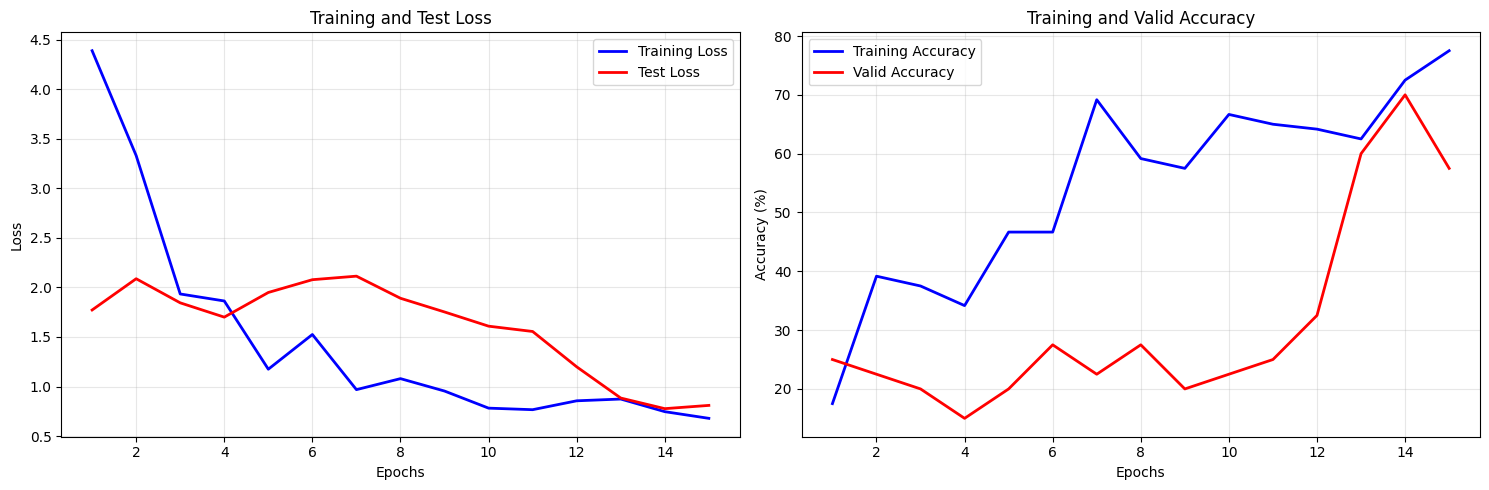

In [18]:
from torch.utils.data import DataLoader
from IPython.display import clear_output

# Initialize datasets & dataloaders
train_data = train_dataset
valid_data = valid_dataset

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)  # ИСПРАВЛЕНО: test_dataset вместо test_df

# Model, Loss, Optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SoundClassificationModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

n_epochs = 15

for epoch in range(n_epochs):
    # Train
    model.train()
    train_loss_epoch = 0.0
    train_correct = 0
    train_total = 0

    for signals, labels in train_loader:
        signals, labels = signals.to(device), labels.to(device)
        
        predictions = model(signals)
        train_loss = criterion(predictions, labels)
        
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        
        train_loss_epoch += train_loss.item()
        train_correct += (predictions.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    # Evaluation
    model.eval()
    valid_loss_epoch = 0.0
    valid_correct = 0
    valid_total = 0
    with torch.no_grad():
        for signals, labels in valid_loader:
            signals, labels = signals.to(device), labels.to(device)
            
            predictions = model(signals)
            valid_loss = criterion(predictions, labels)
            
            valid_loss_epoch += valid_loss.item()
            valid_correct += (predictions.argmax(1) == labels).sum().item()
            valid_total += labels.size(0)

    epoch_train_loss = train_loss_epoch / len(train_loader)
    epoch_train_acc = 100.0 * train_correct / train_total

    epoch_valid_loss = valid_loss_epoch / len(valid_loader)
    epoch_valid_acc = 100.0 * valid_correct / valid_total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_valid_acc)

    plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)
    clear_output(wait=True)

In [19]:
print("Train Accuracy = ", train_accuracies[-1])
print("Valid Accuracy = ", valid_accuracies[-1])

Train Accuracy =  77.5
Valid Accuracy =  57.5


### **Part 4. Test Demo for ESC-50**

Для вашего удобства предоставляется код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

Using device: cpu
ESC-50 Audio Classification Demo!


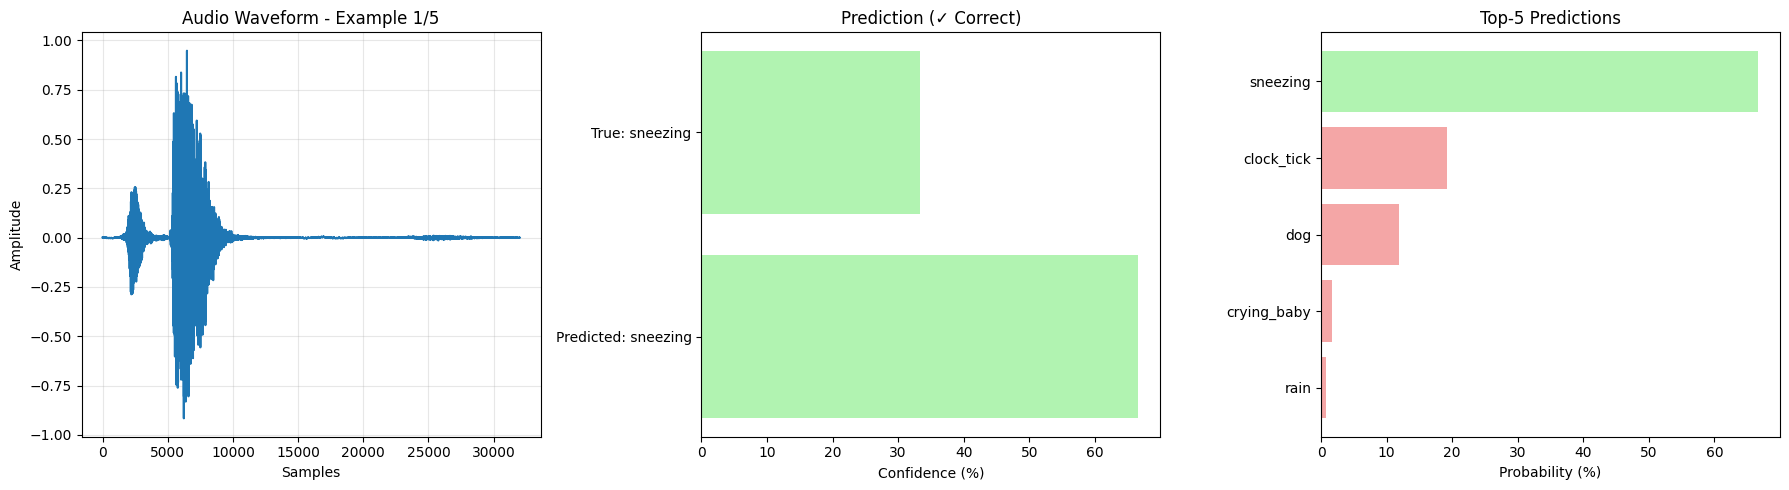

Playing: sneezing


Prediction: sneezing (66.66%)
True label: sneezing
Correct: True


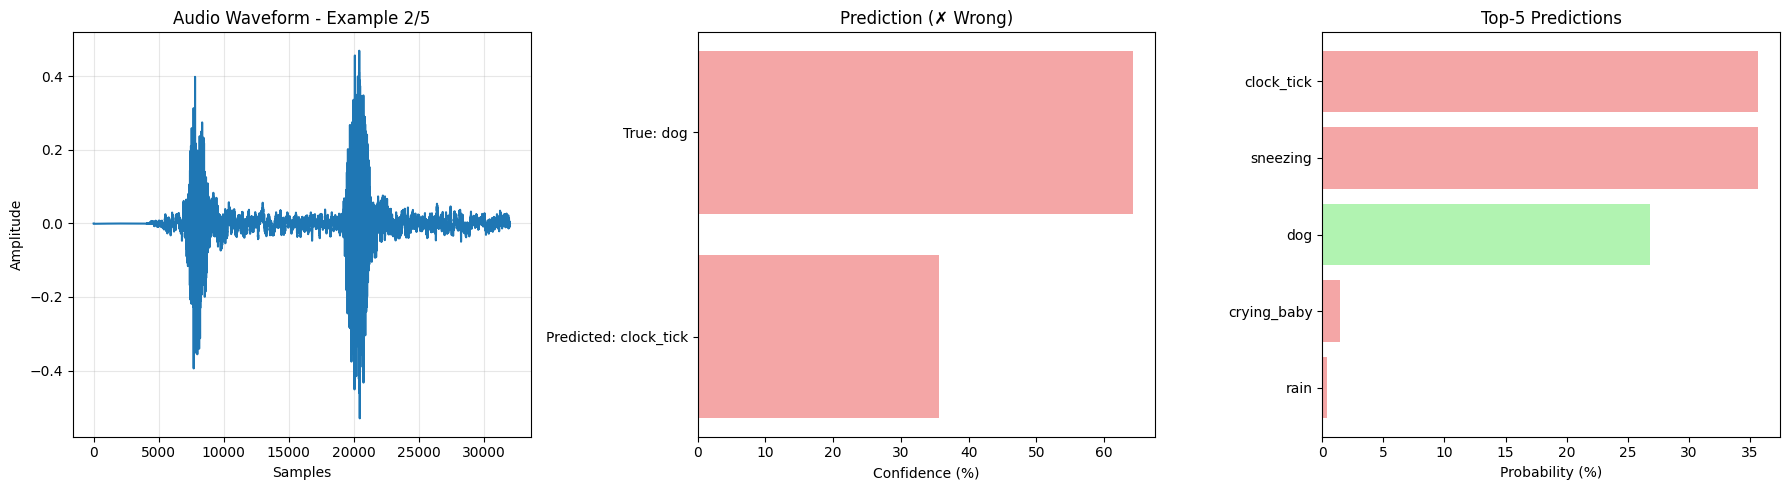

Playing: dog


Prediction: clock_tick (35.67%)
True label: dog
Correct: False


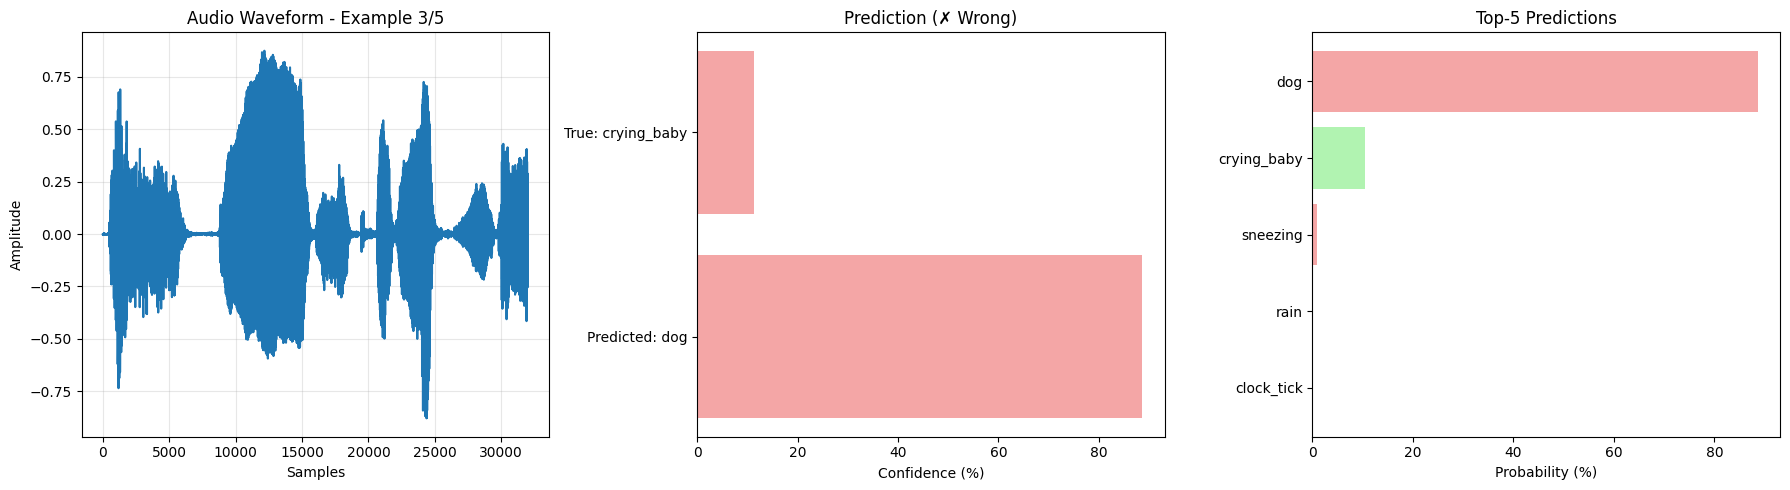

Playing: crying_baby


In [ ]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = test_dataset.classes
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_dataset, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### **Create submission to Stepik**

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [ ]:
model.eval()
y_test_pred = []
with torch.no_grad():
    for signals, _ in test_loader:
        signals = signals.to(device)
        outputs = model(signals)
        _, predicted = torch.max(outputs, 1)
        y_test_pred.extend(predicted.cpu().numpy())

# Создаем словарь для преобразования индексов в названия классов
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

# Преобразуем предсказанные индексы в названия классов
y_test_pred_classes = [idx_to_class[idx] for idx in y_test_pred]

In [ ]:
# Создаем submission файл с правильными названиями классов
submission = pd.read_csv("data/test.csv")
submission['category'] = y_test_pred_classes
submission.to_csv("submission_1.csv", index=False)

# Проверим первые несколько строк
print(submission.head())

            filename     category
0  5-151085-A-20.wav  crying_baby
1  5-181766-A-10.wav  crying_baby
2  5-187979-A-21.wav          dog
3  5-188655-A-10.wav         rain
4  5-193339-A-10.wav         rain


### **Report**

Опишите ваш путь экспериментов и что вы сделали, чтобы получить наилучшую модель.